In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 2.3.3
numpy: 2.2.5


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("../Result")
SEEDS = list(range(15))

MAX_EPISODES = 8000
MAX_STEPS = 250
VALIDATION_INTERVAL = 800
EVALUATION_BATCH_SIZE = 5

print("Results folder:", RESULTS_DIR.resolve())
print("Exists:", RESULTS_DIR.exists())

Results folder: C:\Users\Gururaj Shetty\Reinforcement_Learning_HandsOn\MultiSeed\Hardware\Result
Exists: True


In [6]:
for seed in SEEDS:
    seed_dir = RESULTS_DIR / f"seed_{seed}"
    print(f"seed_{seed}:", seed_dir.exists())

seed_0: True
seed_1: True
seed_2: True
seed_3: True
seed_4: True
seed_5: True
seed_6: True
seed_7: True
seed_8: True
seed_9: True
seed_10: True
seed_11: True
seed_12: True
seed_13: True
seed_14: True


In [7]:
training_data = {}
validation_data = {}
evaluation_data = {}
performance_data = {}

for seed in SEEDS:
    seed_dir = RESULTS_DIR / f"seed_{seed}"

    training_data[seed] = pd.read_csv(seed_dir / "training_metrics.csv")
    validation_data[seed] = pd.read_csv(seed_dir / "validation_summary.csv")
    evaluation_data[seed] = pd.read_csv(seed_dir / "evaluation_summary.csv")
    performance_data[seed] = pd.read_csv(seed_dir / "hardware_performance_metrics_strict.csv")

print("Loaded", len(SEEDS), "hardware seed results.")

Loaded 15 hardware seed results.


In [8]:
summary_rows = []

for seed in SEEDS:
    perf = performance_data[seed].iloc[0]

    summary_rows.append({
        "seed": seed,
        "average_evaluation_reward": float(perf["average_evaluation_reward"]),
        "average_stable_accuracy": float(perf["average_stable_accuracy"]),
        "success_rate": float(perf["success_rate"]),
        "f1_score": float(perf["f1_score"]),
        "tp": int(perf["tp"]),
        "fn": int(perf["fn"]),
    })

summary_df = pd.DataFrame(summary_rows)

def classify_seed(f1):
    if f1 > 0.8:
        return "Strong"
    elif f1 >= 0.5:
        return "Moderate"
    else:
        return "Weak"

summary_df["group"] = summary_df["f1_score"].apply(classify_seed)

summary_df

,seed,average_evaluation_reward,average_stable_accuracy,success_rate,f1_score,tp,fn,group
0,0,2030.827661,0.8128,1.0,0.896734,1016,234,Strong
1,1,1246.757592,0.5040,0.6,0.670213,630,620,Moderate
2,2,2072.468604,0.8240,1.0,0.903509,1030,220,Strong
3,3,105.753957,0.0152,0.0,0.029945,19,1231,Weak
4,4,1630.848041,0.6576,0.8,0.793436,822,428,Moderate
5,5,318.065534,0.1464,0.2,0.255408,183,1067,Weak
6,6,2144.444727,0.8528,1.0,0.920553,1066,184,Strong
7,7,1744.596764,0.6904,0.8,0.816848,863,387,Strong
8,8,-2.226219,0.0000,0.0,0.000000,0,1250,Weak
9,9,1893.213745,0.7744,1.0,0.872858,968,282,Strong


In [9]:
group_counts = summary_df["group"].value_counts()
group_counts

group
Strong      10
Weak         3
Moderate     2
Name: count, dtype: int64

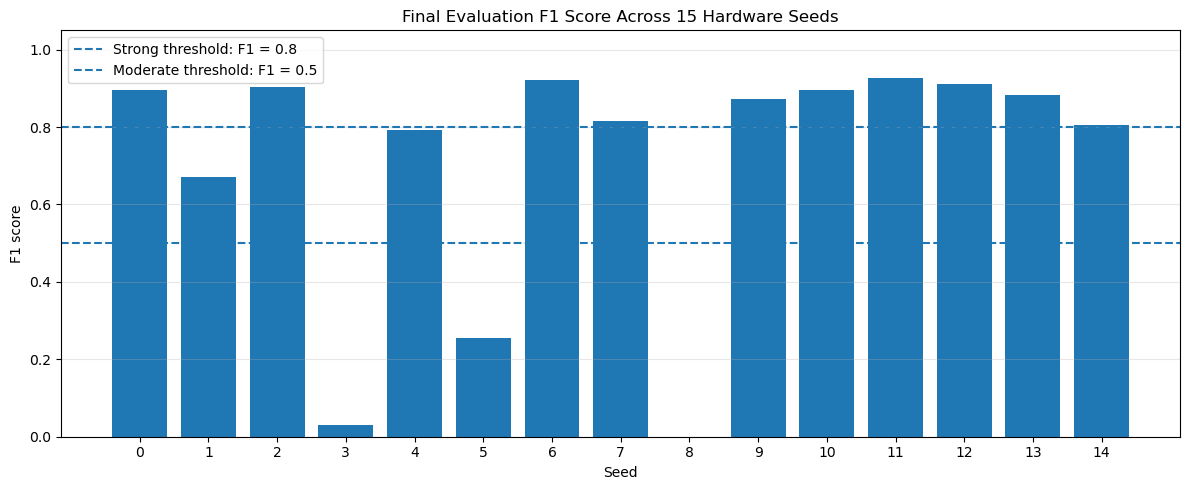

In [10]:
plt.figure(figsize=(12, 5))

plt.bar(summary_df["seed"].astype(str), summary_df["f1_score"])

plt.axhline(0.8, linestyle="--", label="Strong threshold: F1 = 0.8")
plt.axhline(0.5, linestyle="--", label="Moderate threshold: F1 = 0.5")

plt.xlabel("Seed")
plt.ylabel("F1 score")
plt.title("Final Evaluation F1 Score Across 15 Hardware Seeds")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
best_seed = int(summary_df.sort_values("f1_score", ascending=False).iloc[0]["seed"])
worst_seed = int(summary_df.sort_values("f1_score", ascending=True).iloc[0]["seed"])

moderate_df = summary_df[summary_df["group"] == "Moderate"].sort_values("f1_score")

if len(moderate_df) > 0:
    middle_seed = int(moderate_df.iloc[len(moderate_df) // 2]["seed"])
else:
    middle_seed = int(summary_df.sort_values("f1_score").iloc[len(summary_df)//2]["seed"])

selected_seeds = [best_seed, middle_seed, worst_seed]

print("Best seed:", best_seed)
print("Moderate seed:", middle_seed)
print("Worst seed:", worst_seed)
print("Selected seeds:", selected_seeds)

Best seed: 11
Moderate seed: 4
Worst seed: 8
Selected seeds: [11, 4, 8]


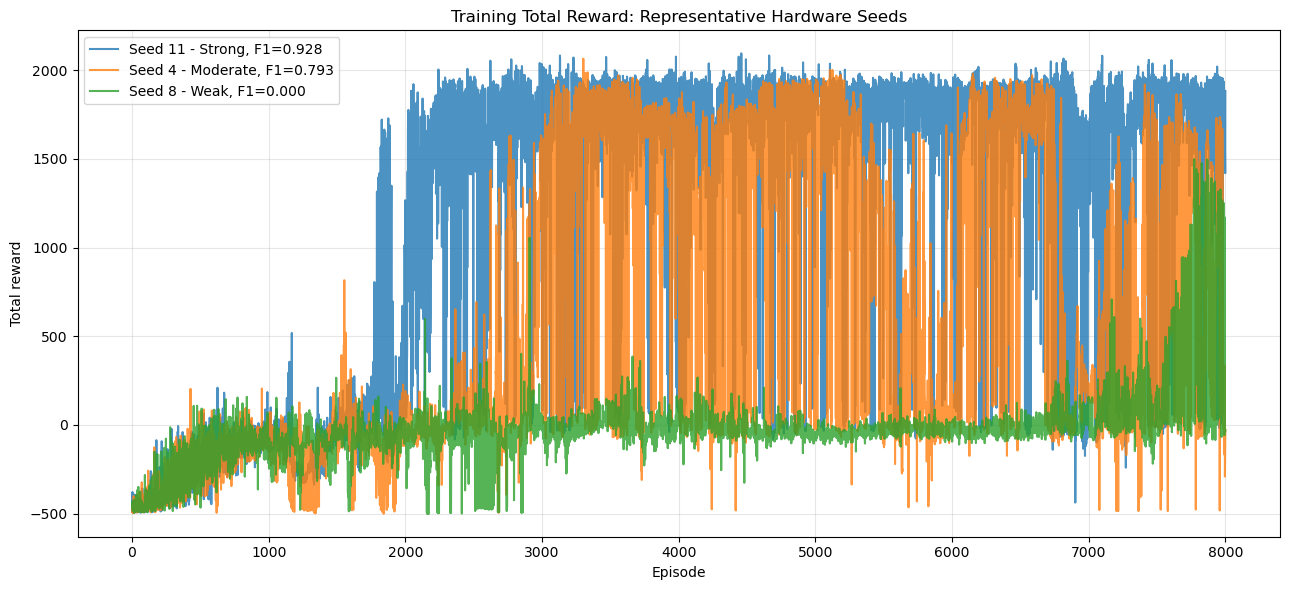

In [12]:
plt.figure(figsize=(13, 6))

for seed in selected_seeds:
    df = training_data[seed]
    group = summary_df.loc[summary_df["seed"] == seed, "group"].iloc[0]
    f1 = summary_df.loc[summary_df["seed"] == seed, "f1_score"].iloc[0]

    plt.plot(
        df["episode"],
        df["total_reward"],
        label=f"Seed {seed} - {group}, F1={f1:.3f}",
        alpha=0.8
    )

plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.title("Training Total Reward: Representative Hardware Seeds")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

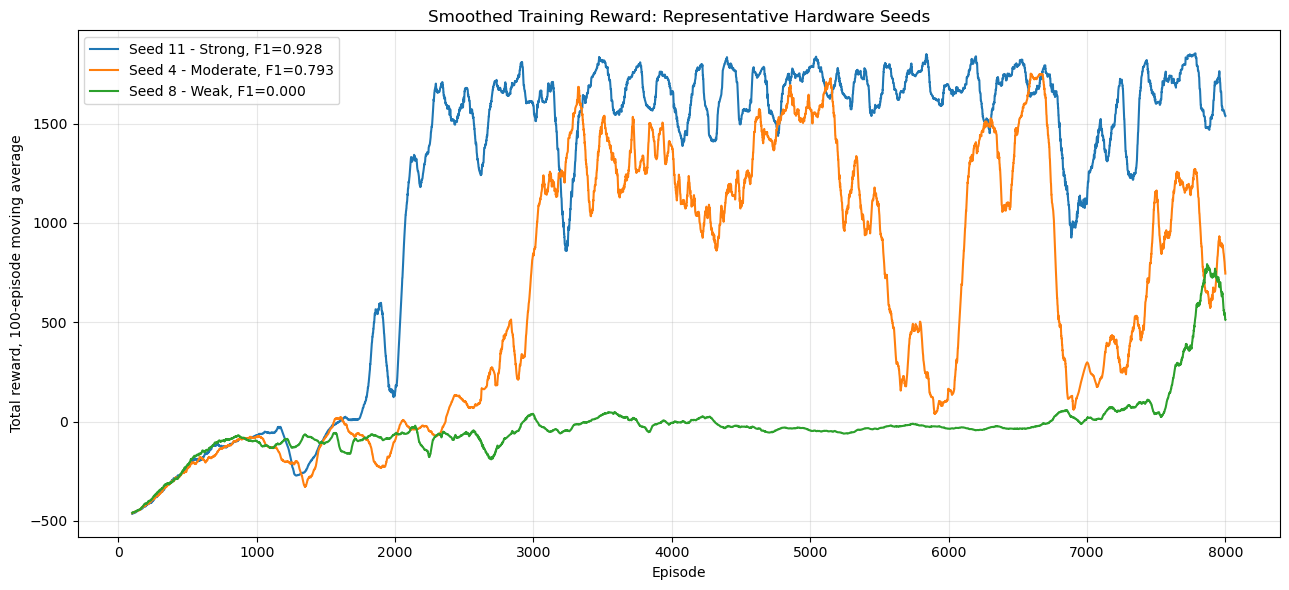

In [13]:
WINDOW = 100

plt.figure(figsize=(13, 6))

for seed in selected_seeds:
    df = training_data[seed].copy()
    df["reward_smooth"] = df["total_reward"].rolling(WINDOW).mean()

    group = summary_df.loc[summary_df["seed"] == seed, "group"].iloc[0]
    f1 = summary_df.loc[summary_df["seed"] == seed, "f1_score"].iloc[0]

    plt.plot(
        df["episode"],
        df["reward_smooth"],
        label=f"Seed {seed} - {group}, F1={f1:.3f}"
    )

plt.xlabel("Episode")
plt.ylabel(f"Total reward, {WINDOW}-episode moving average")
plt.title("Smoothed Training Reward: Representative Hardware Seeds")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

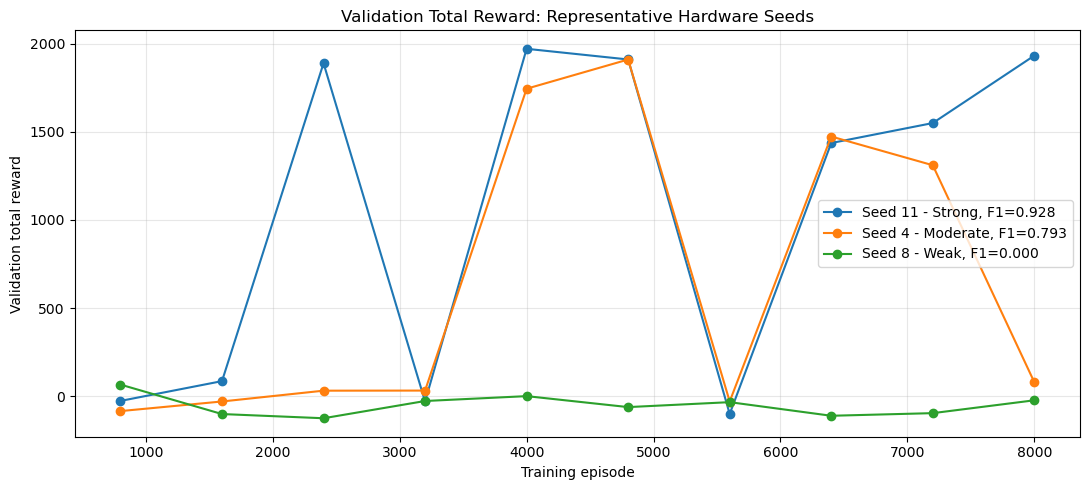

In [14]:
plt.figure(figsize=(11, 5))

for seed in selected_seeds:
    df = validation_data[seed]
    group = summary_df.loc[summary_df["seed"] == seed, "group"].iloc[0]
    f1 = summary_df.loc[summary_df["seed"] == seed, "f1_score"].iloc[0]

    plt.plot(
        df["training_episode"],
        df["total_reward"],
        marker="o",
        label=f"Seed {seed} - {group}, F1={f1:.3f}"
    )

plt.xlabel("Training episode")
plt.ylabel("Validation total reward")
plt.title("Validation Total Reward: Representative Hardware Seeds")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

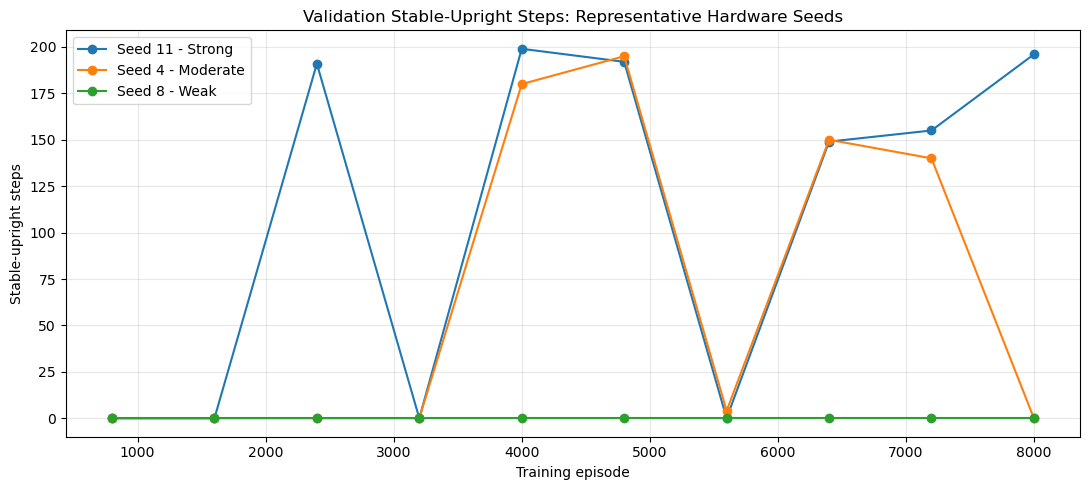

In [15]:
plt.figure(figsize=(11, 5))

for seed in selected_seeds:
    df = validation_data[seed]
    group = summary_df.loc[summary_df["seed"] == seed, "group"].iloc[0]

    plt.plot(
        df["training_episode"],
        df["stable_upright_steps"],
        marker="o",
        label=f"Seed {seed} - {group}"
    )

plt.xlabel("Training episode")
plt.ylabel("Stable-upright steps")
plt.title("Validation Stable-Upright Steps: Representative Hardware Seeds")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
all_rewards = []

for seed in SEEDS:
    df = training_data[seed][["episode", "total_reward"]].copy()
    df = df.rename(columns={"total_reward": f"seed_{seed}"})
    all_rewards.append(df)

mean_training = all_rewards[0]

for df in all_rewards[1:]:
    mean_training = mean_training.merge(df, on="episode")

seed_cols = [f"seed_{seed}" for seed in SEEDS]

mean_training["mean_total_reward"] = mean_training[seed_cols].mean(axis=1)
mean_training["std_total_reward"] = mean_training[seed_cols].std(axis=1)

mean_training["mean_total_reward_smooth"] = mean_training["mean_total_reward"].rolling(WINDOW).mean()
mean_training["std_total_reward_smooth"] = mean_training["std_total_reward"].rolling(WINDOW).mean()

mean_training.head()

,episode,seed_0,seed_1,seed_2,seed_3,seed_4,seed_5,seed_6,seed_7,seed_8,seed_9,seed_10,seed_11,seed_12,seed_13,seed_14,mean_total_reward,std_total_reward,mean_total_reward_smooth,std_total_reward_smooth
0,1,-462.129028,-456.914185,-454.367065,-454.505188,-473.188599,-480.341736,-485.014252,-493.282776,-470.901062,-478.645874,-492.872192,-476.467834,-487.725159,-453.917816,-488.694336,-473.931140,14.474914,NaN,NaN
1,2,-456.102600,-431.049896,-474.790497,-496.125092,-483.733093,-483.686554,-451.996582,-477.639404,-463.518066,-485.458832,-473.677429,-484.245972,-481.181213,-469.923859,-486.563416,-473.312834,16.704003,NaN,NaN
2,3,-480.726624,-490.406342,-489.622253,-483.921844,-492.176758,-473.558289,-436.912170,-494.434509,-429.506683,-450.649841,-479.009338,-378.417847,-489.006989,-487.799469,-495.172455,-470.088094,32.842556,NaN,NaN
3,4,-492.250122,-447.469177,-481.544403,-472.327789,-451.353577,-495.860535,-492.981995,-439.723511,-450.517273,-478.876465,-450.072968,-492.108093,-494.568359,-488.327606,-486.027649,-474.267301,20.476742,NaN,NaN
4,5,-481.644257,-481.031464,-458.525391,-418.869446,-494.932709,-489.278717,-479.874878,-491.913788,-469.855286,-489.918427,-462.716614,-484.336639,-485.416779,-483.570343,-495.389740,-477.818298,19.601846,NaN,NaN


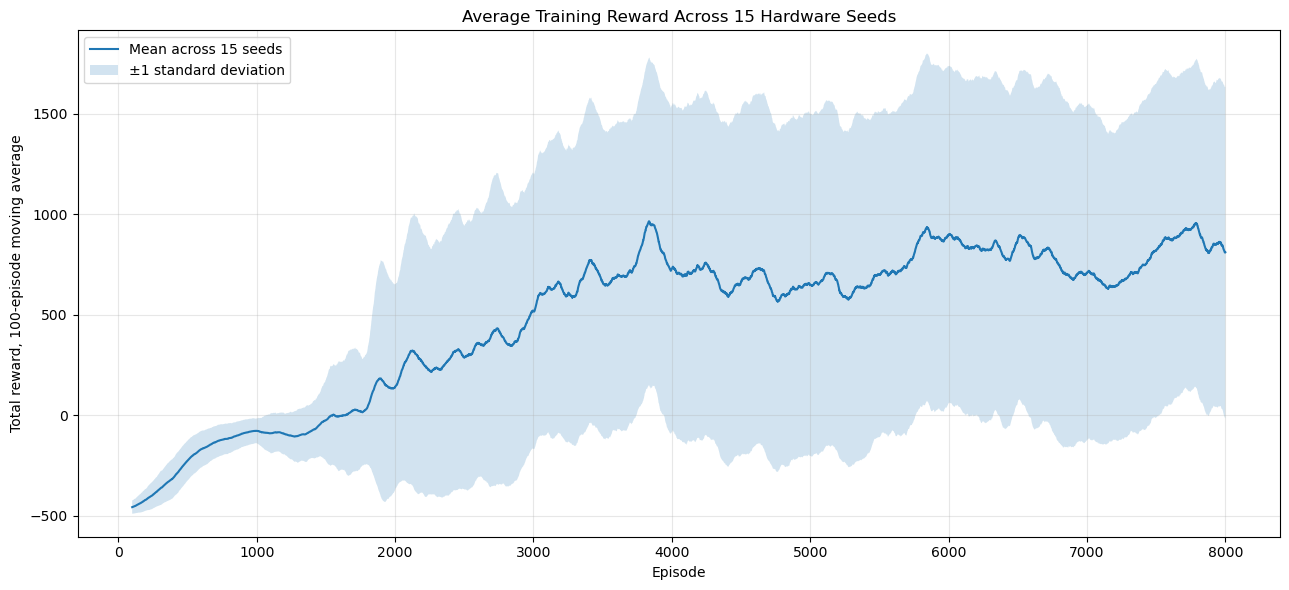

In [17]:
plt.figure(figsize=(13, 6))

x = mean_training["episode"]
mean = mean_training["mean_total_reward_smooth"]
std = mean_training["std_total_reward_smooth"]

plt.plot(x, mean, label="Mean across 15 seeds")
plt.fill_between(x, mean - std, mean + std, alpha=0.2, label="±1 standard deviation")

plt.xlabel("Episode")
plt.ylabel(f"Total reward, {WINDOW}-episode moving average")
plt.title("Average Training Reward Across 15 Hardware Seeds")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
all_validation_rewards = []

for seed in SEEDS:
    df = validation_data[seed][["training_episode", "total_reward"]].copy()
    df = df.rename(columns={"total_reward": f"seed_{seed}"})
    all_validation_rewards.append(df)

mean_validation_reward = all_validation_rewards[0]

for df in all_validation_rewards[1:]:
    mean_validation_reward = mean_validation_reward.merge(df, on="training_episode")

seed_cols = [f"seed_{seed}" for seed in SEEDS]

mean_validation_reward["mean_validation_reward"] = mean_validation_reward[seed_cols].mean(axis=1)
mean_validation_reward["std_validation_reward"] = mean_validation_reward[seed_cols].std(axis=1)

mean_validation_reward

,training_episode,seed_0,seed_1,seed_2,seed_3,seed_4,seed_5,seed_6,seed_7,seed_8,seed_9,seed_10,seed_11,seed_12,seed_13,seed_14,mean_validation_reward,std_validation_reward
0,800,-11.493572,-3.986201,76.383415,37.636066,-83.744766,-91.030060,-97.433472,-58.560337,66.490585,-100.600243,-86.501755,-26.079475,-92.810997,20.418755,-67.367134,-34.578613,62.082419
1,1600,1822.512695,23.808445,85.072952,-82.546318,-29.235720,-85.631508,-17.765764,-438.990936,-100.519867,94.897034,-52.536686,86.155762,-499.843628,-99.403862,-62.364986,42.907174,521.171634
2,2400,-499.843628,1698.281860,1793.122559,-139.894333,31.991657,-210.275787,59.566494,-98.966835,-124.327835,865.095764,-106.127388,1888.510742,-38.891830,17.226521,-29.403595,340.404291,803.277992
3,3200,46.766365,1741.420898,1750.112793,-0.727266,32.565632,100.317329,-75.678253,-499.843628,-26.527769,221.330200,672.528137,-29.211191,1374.499390,-55.888309,109.618011,357.418823,699.761552
4,4000,-173.177017,1706.809570,31.350197,48.599373,1743.944092,1725.395508,1906.262817,1678.795532,1.060015,1350.839844,17.772547,1970.265625,38.487228,399.044983,-499.888733,796.370772,926.652950
5,4800,-126.840981,-499.999969,1713.358276,-0.152565,1909.552734,71.112061,1702.499390,1896.551270,-61.100758,-497.572052,-2.302749,1909.823364,-499.999969,1678.091064,-18.774321,611.616320,1024.782581
6,5600,-70.449020,1693.406738,-499.999969,-66.861641,-29.454124,42.486046,1677.719971,1855.262939,-33.123642,41.734974,-499.843628,-99.938118,-499.999969,108.629646,-33.128918,239.096086,804.209526
7,6400,-4.664726,1791.676392,1765.141724,-31.790052,1473.004395,1136.849609,1518.520874,-43.229053,-110.243446,-74.575859,328.419830,1436.005127,1767.180664,53.403015,644.890381,776.705925,791.791477
8,7200,95.642250,1616.410889,1880.472168,-76.179489,1310.190674,1530.731445,-499.843628,1276.614502,-95.377052,-37.917385,-66.593361,1549.268799,1713.222290,353.067535,-499.843628,669.991067,890.214685
9,8000,22.800097,1713.931396,1717.389771,-183.517334,80.230904,1122.188965,1361.378052,1938.278564,-22.559818,-110.707176,1678.942993,1931.620117,1605.103394,-499.999969,1814.369141,944.629940,929.415456


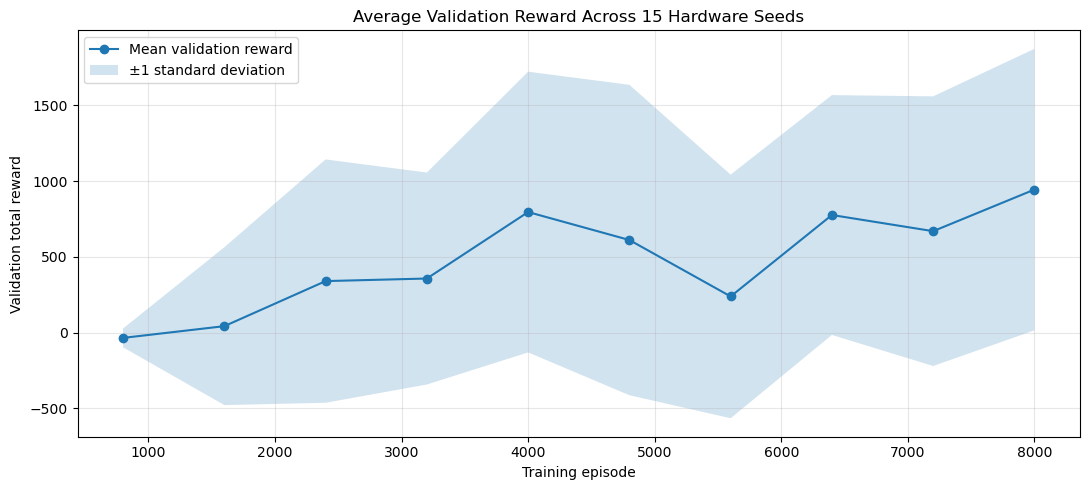

In [19]:
plt.figure(figsize=(11, 5))

x = mean_validation_reward["training_episode"]
mean = mean_validation_reward["mean_validation_reward"]
std = mean_validation_reward["std_validation_reward"]

plt.plot(x, mean, marker="o", label="Mean validation reward")
plt.fill_between(x, mean - std, mean + std, alpha=0.2, label="±1 standard deviation")

plt.xlabel("Training episode")
plt.ylabel("Validation total reward")
plt.title("Average Validation Reward Across 15 Hardware Seeds")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
all_validation_stable = []

for seed in SEEDS:
    df = validation_data[seed][["training_episode", "stable_upright_steps"]].copy()
    df = df.rename(columns={"stable_upright_steps": f"seed_{seed}"})
    all_validation_stable.append(df)

mean_validation_stable = all_validation_stable[0]

for df in all_validation_stable[1:]:
    mean_validation_stable = mean_validation_stable.merge(df, on="training_episode")

seed_cols = [f"seed_{seed}" for seed in SEEDS]

mean_validation_stable["mean_stable_steps"] = mean_validation_stable[seed_cols].mean(axis=1)
mean_validation_stable["std_stable_steps"] = mean_validation_stable[seed_cols].std(axis=1)

mean_validation_stable

,training_episode,seed_0,seed_1,seed_2,seed_3,seed_4,seed_5,seed_6,seed_7,seed_8,seed_9,seed_10,seed_11,seed_12,seed_13,seed_14,mean_stable_steps,std_stable_steps
0,800,0,4,0,0,0,0,0,0,0,0,0,0,0,0,2,0.400000,1.121224
1,1600,186,0,0,0,0,0,0,0,0,25,0,0,0,0,0,14.066667,47.997718
2,2400,0,177,185,0,0,0,0,0,0,93,0,191,0,0,0,43.066667,76.933614
3,3200,1,177,175,0,0,0,0,0,0,29,185,0,177,0,0,49.600000,80.820613
4,4000,0,179,0,3,180,174,192,169,0,143,0,199,0,114,0,90.200000,89.105235
5,4800,0,0,174,0,195,8,173,191,0,0,0,192,0,172,0,73.666667,92.513062
6,5600,0,173,0,0,4,8,171,188,0,0,0,0,0,7,0,36.733333,72.900585
7,6400,0,182,180,0,150,117,160,0,0,0,23,149,179,7,180,88.466667,83.297116
8,7200,0,165,192,0,140,156,0,136,0,0,0,155,175,18,0,75.800000,82.509913
9,8000,0,175,174,0,0,183,141,195,0,0,171,196,170,0,186,106.066667,90.513193


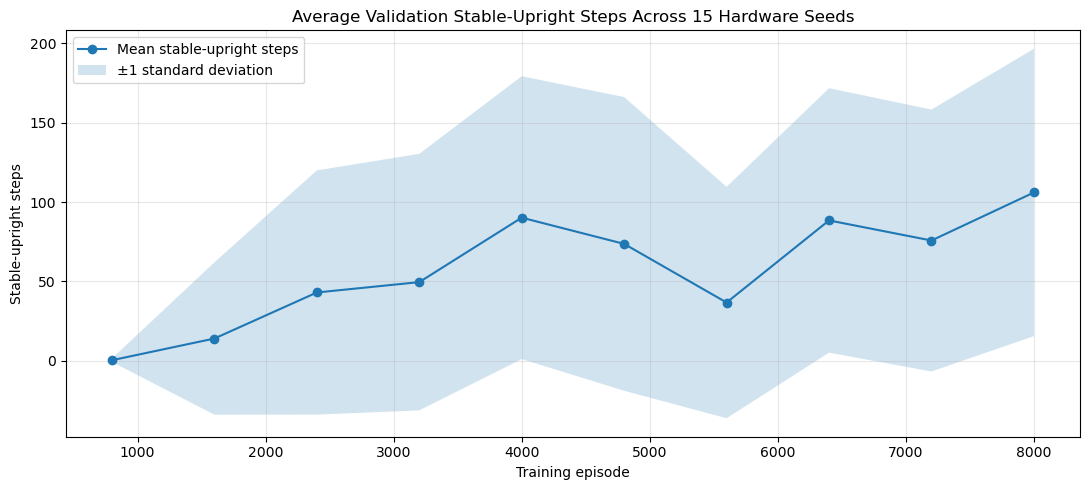

In [21]:
plt.figure(figsize=(11, 5))

x = mean_validation_stable["training_episode"]
mean = mean_validation_stable["mean_stable_steps"]
std = mean_validation_stable["std_stable_steps"]

plt.plot(x, mean, marker="o", label="Mean stable-upright steps")
plt.fill_between(x, mean - std, mean + std, alpha=0.2, label="±1 standard deviation")

plt.xlabel("Training episode")
plt.ylabel("Stable-upright steps")
plt.title("Average Validation Stable-Upright Steps Across 15 Hardware Seeds")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
zero_f1_seeds = summary_df[summary_df["f1_score"] == 0]["seed"].tolist()

print("Seeds with F1 = 0:", zero_f1_seeds)

for seed in zero_f1_seeds:
    print("\nSeed:", seed)
    display(evaluation_data[seed][[
        "evaluation_batch",
        "total_reward",
        "upright_steps",
        "stable_upright_steps",
        "max_consecutive_stable_steps",
        "success"
    ]])

    total_upright = evaluation_data[seed]["upright_steps"].sum()
    total_stable = evaluation_data[seed]["stable_upright_steps"].sum()

    print("Total upright steps:", total_upright)
    print("Total stable-upright steps:", total_stable)

Seeds with F1 = 0: [8]

Seed: 8


,evaluation_batch,total_reward,upright_steps,stable_upright_steps,max_consecutive_stable_steps,success
0,0,66.490585,39,0,0,0
1,1,-65.953499,32,0,0,0
2,2,-58.422886,33,0,0,0
3,3,-50.050289,31,0,0,0
4,4,96.804993,43,0,0,0


Total upright steps: 178
Total stable-upright steps: 0


In [23]:
OUTPUT_DIR = RESULTS_DIR / "notebook_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

summary_df.to_csv(OUTPUT_DIR / "seed_summary_from_notebook.csv", index=False)
mean_training.to_csv(OUTPUT_DIR / "mean_training_reward.csv", index=False)
mean_validation_reward.to_csv(OUTPUT_DIR / "mean_validation_reward.csv", index=False)
mean_validation_stable.to_csv(OUTPUT_DIR / "mean_validation_stable_steps.csv", index=False)

print("Saved notebook output files to:")
print(OUTPUT_DIR.resolve())

Saved notebook output files to:
C:\Users\Gururaj Shetty\Reinforcement_Learning_HandsOn\MultiSeed\Hardware\Result\notebook_outputs


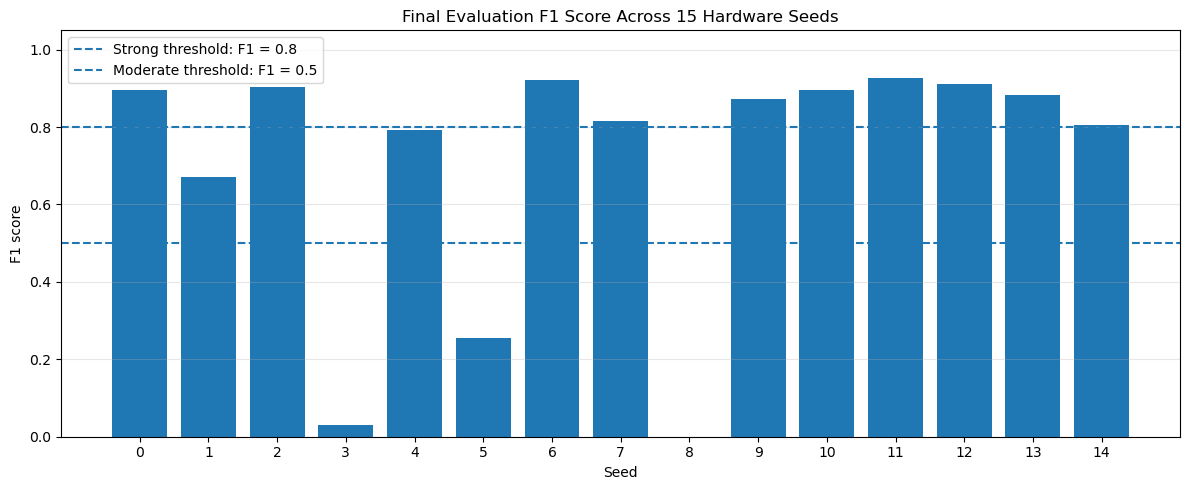

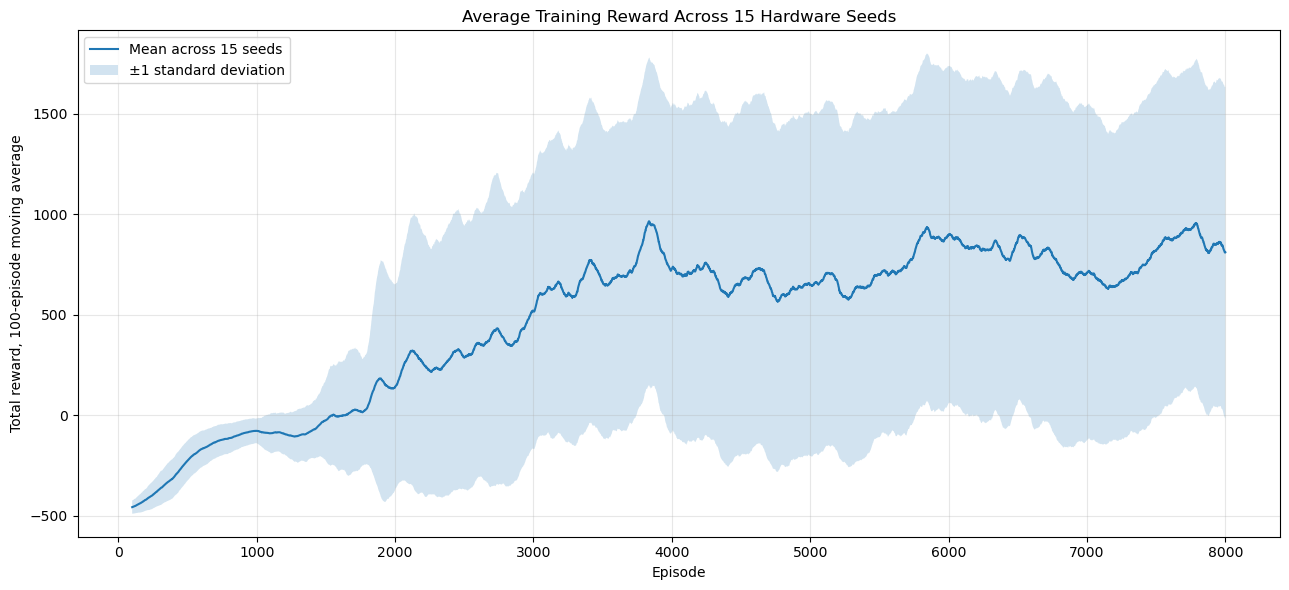

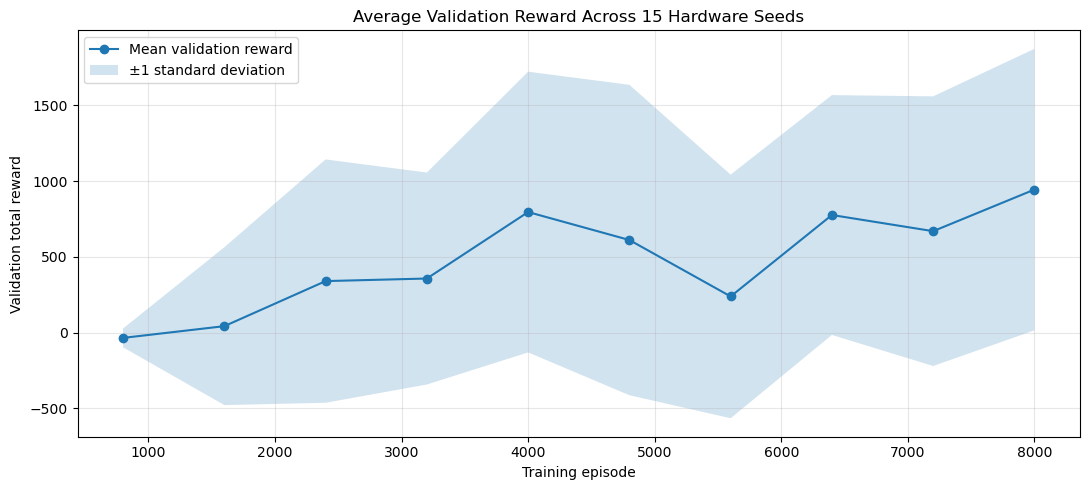

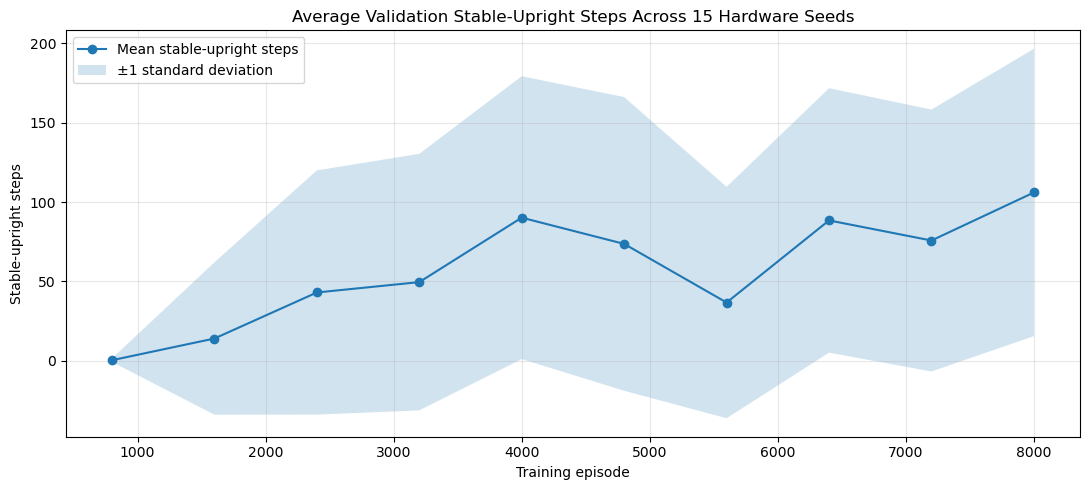

Saved plots to:
C:\Users\Gururaj Shetty\Reinforcement_Learning_HandsOn\MultiSeed\Hardware\Result\notebook_outputs\plots


In [24]:
PLOT_DIR = OUTPUT_DIR / "plots"
PLOT_DIR.mkdir(exist_ok=True)

# F1 plot
plt.figure(figsize=(12, 5))
plt.bar(summary_df["seed"].astype(str), summary_df["f1_score"])
plt.axhline(0.8, linestyle="--", label="Strong threshold: F1 = 0.8")
plt.axhline(0.5, linestyle="--", label="Moderate threshold: F1 = 0.5")
plt.xlabel("Seed")
plt.ylabel("F1 score")
plt.title("Final Evaluation F1 Score Across 15 Hardware Seeds")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "f1_score_per_seed.png", dpi=300)
plt.show()

# Average training reward
plt.figure(figsize=(13, 6))
x = mean_training["episode"]
mean = mean_training["mean_total_reward_smooth"]
std = mean_training["std_total_reward_smooth"]
plt.plot(x, mean, label="Mean across 15 seeds")
plt.fill_between(x, mean - std, mean + std, alpha=0.2, label="±1 standard deviation")
plt.xlabel("Episode")
plt.ylabel(f"Total reward, {WINDOW}-episode moving average")
plt.title("Average Training Reward Across 15 Hardware Seeds")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "average_training_reward_all_seeds.png", dpi=300)
plt.show()

# Average validation reward
plt.figure(figsize=(11, 5))
x = mean_validation_reward["training_episode"]
mean = mean_validation_reward["mean_validation_reward"]
std = mean_validation_reward["std_validation_reward"]
plt.plot(x, mean, marker="o", label="Mean validation reward")
plt.fill_between(x, mean - std, mean + std, alpha=0.2, label="±1 standard deviation")
plt.xlabel("Training episode")
plt.ylabel("Validation total reward")
plt.title("Average Validation Reward Across 15 Hardware Seeds")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "average_validation_reward_all_seeds.png", dpi=300)
plt.show()

# Average stable steps
plt.figure(figsize=(11, 5))
x = mean_validation_stable["training_episode"]
mean = mean_validation_stable["mean_stable_steps"]
std = mean_validation_stable["std_stable_steps"]
plt.plot(x, mean, marker="o", label="Mean stable-upright steps")
plt.fill_between(x, mean - std, mean + std, alpha=0.2, label="±1 standard deviation")
plt.xlabel("Training episode")
plt.ylabel("Stable-upright steps")
plt.title("Average Validation Stable-Upright Steps Across 15 Hardware Seeds")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "average_validation_stable_steps_all_seeds.png", dpi=300)
plt.show()

print("Saved plots to:")
print(PLOT_DIR.resolve())

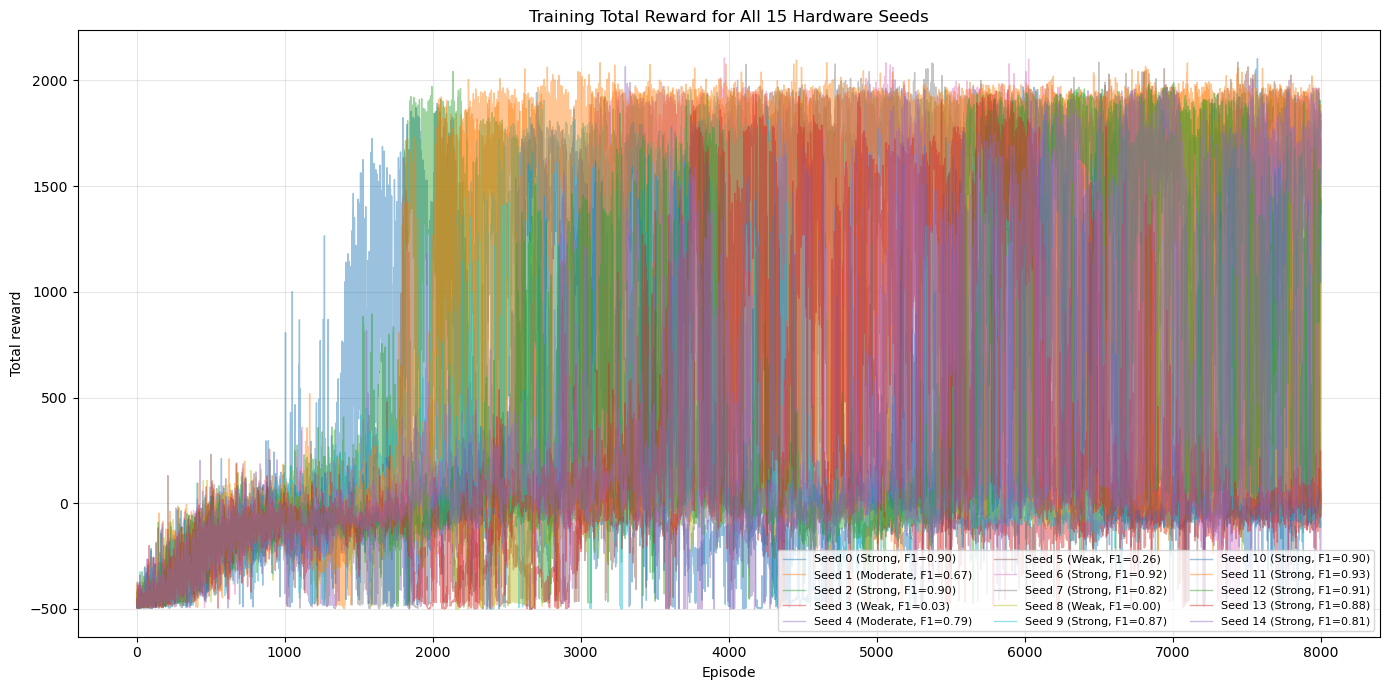

In [25]:
plt.figure(figsize=(14, 7))

for seed in SEEDS:
    df = training_data[seed]
    f1 = summary_df.loc[summary_df["seed"] == seed, "f1_score"].iloc[0]
    group = summary_df.loc[summary_df["seed"] == seed, "group"].iloc[0]

    plt.plot(
        df["episode"],
        df["total_reward"],
        alpha=0.45,
        linewidth=1.0,
        label=f"Seed {seed} ({group}, F1={f1:.2f})"
    )

plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.title("Training Total Reward for All 15 Hardware Seeds")
plt.grid(alpha=0.3)
plt.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

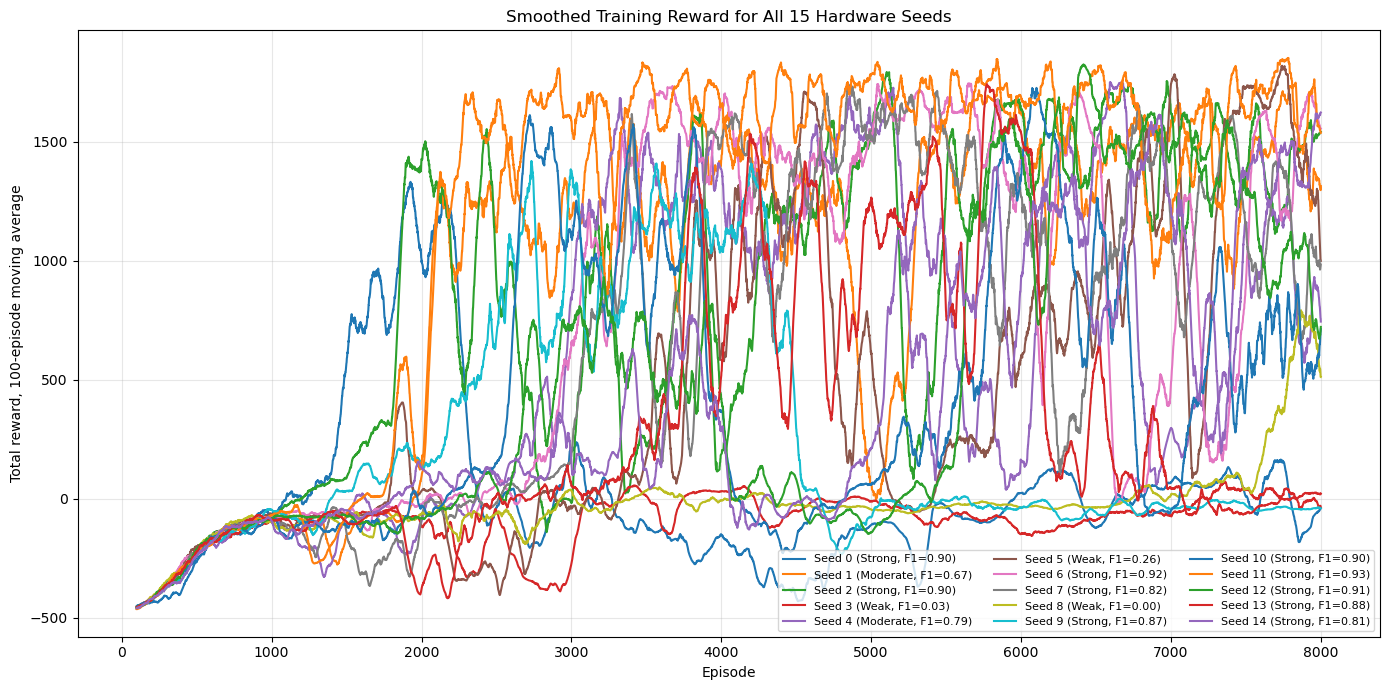

In [26]:
WINDOW = 100

plt.figure(figsize=(14, 7))

for seed in SEEDS:
    df = training_data[seed].copy()
    df["reward_smooth"] = df["total_reward"].rolling(WINDOW).mean()

    f1 = summary_df.loc[summary_df["seed"] == seed, "f1_score"].iloc[0]
    group = summary_df.loc[summary_df["seed"] == seed, "group"].iloc[0]

    plt.plot(
        df["episode"],
        df["reward_smooth"],
        linewidth=1.5,
        label=f"Seed {seed} ({group}, F1={f1:.2f})"
    )

plt.xlabel("Episode")
plt.ylabel(f"Total reward, {WINDOW}-episode moving average")
plt.title("Smoothed Training Reward for All 15 Hardware Seeds")
plt.grid(alpha=0.3)
plt.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

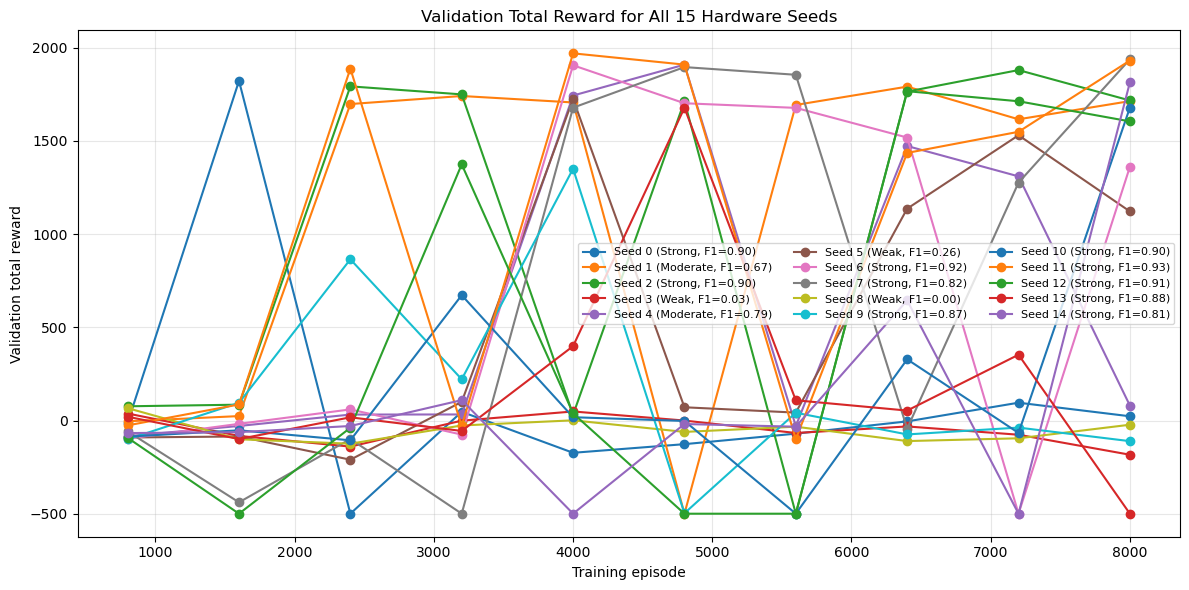

In [27]:
plt.figure(figsize=(12, 6))

for seed in SEEDS:
    df = validation_data[seed]
    f1 = summary_df.loc[summary_df["seed"] == seed, "f1_score"].iloc[0]
    group = summary_df.loc[summary_df["seed"] == seed, "group"].iloc[0]

    plt.plot(
        df["training_episode"],
        df["total_reward"],
        marker="o",
        linewidth=1.5,
        label=f"Seed {seed} ({group}, F1={f1:.2f})"
    )

plt.xlabel("Training episode")
plt.ylabel("Validation total reward")
plt.title("Validation Total Reward for All 15 Hardware Seeds")
plt.grid(alpha=0.3)
plt.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

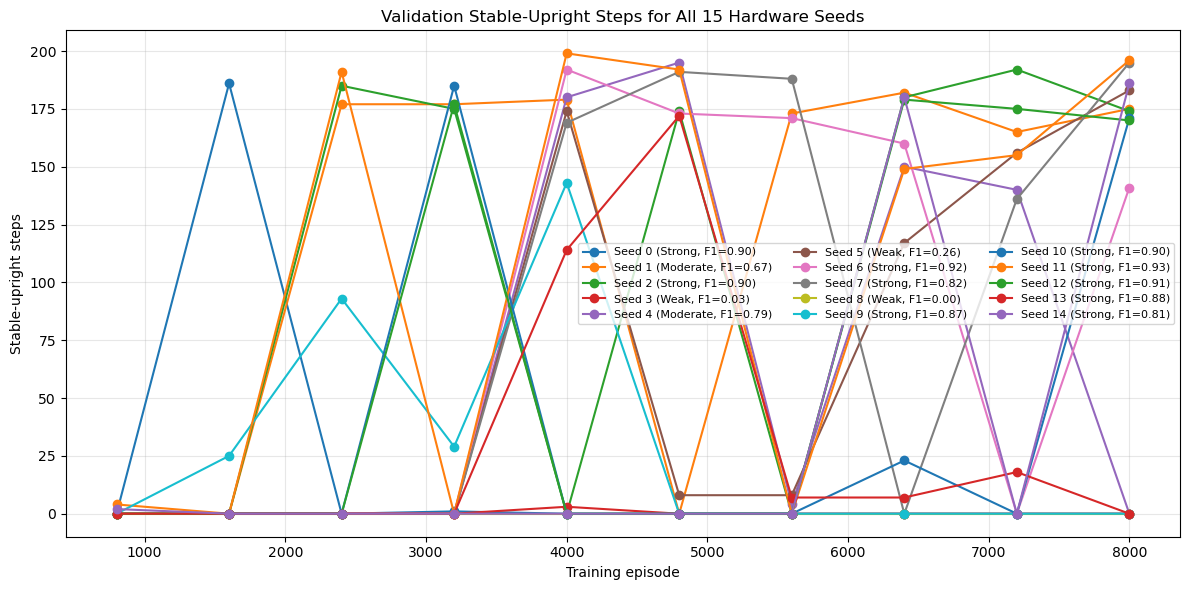

In [28]:
plt.figure(figsize=(12, 6))

for seed in SEEDS:
    df = validation_data[seed]
    f1 = summary_df.loc[summary_df["seed"] == seed, "f1_score"].iloc[0]
    group = summary_df.loc[summary_df["seed"] == seed, "group"].iloc[0]

    plt.plot(
        df["training_episode"],
        df["stable_upright_steps"],
        marker="o",
        linewidth=1.5,
        label=f"Seed {seed} ({group}, F1={f1:.2f})"
    )

plt.xlabel("Training episode")
plt.ylabel("Stable-upright steps")
plt.title("Validation Stable-Upright Steps for All 15 Hardware Seeds")
plt.grid(alpha=0.3)
plt.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

In [29]:
OUTPUT_DIR = RESULTS_DIR / "notebook_outputs"
PLOT_DIR = OUTPUT_DIR / "plots_per_seed"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

WINDOW = 100

for seed in SEEDS:
    df = training_data[seed].copy()
    df["reward_smooth"] = df["total_reward"].rolling(WINDOW).mean()

    f1 = summary_df.loc[summary_df["seed"] == seed, "f1_score"].iloc[0]
    group = summary_df.loc[summary_df["seed"] == seed, "group"].iloc[0]

    plt.figure(figsize=(12, 5))

    plt.plot(
        df["episode"],
        df["total_reward"],
        alpha=0.35,
        label="Raw total reward"
    )

    plt.plot(
        df["episode"],
        df["reward_smooth"],
        linewidth=2.0,
        label=f"{WINDOW}-episode moving average"
    )

    plt.xlabel("Episode")
    plt.ylabel("Total reward")
    plt.title(f"Training Reward - Seed {seed} ({group}, F1={f1:.3f})")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(PLOT_DIR / f"seed_{seed}_training_reward.png", dpi=300)
    plt.close()

print("Saved individual seed training plots to:")
print(PLOT_DIR.resolve())

Saved individual seed training plots to:
C:\Users\Gururaj Shetty\Reinforcement_Learning_HandsOn\MultiSeed\Hardware\Result\notebook_outputs\plots_per_seed


In [30]:
VALIDATION_PLOT_DIR = OUTPUT_DIR / "validation_plots_per_seed"
VALIDATION_PLOT_DIR.mkdir(parents=True, exist_ok=True)

for seed in SEEDS:
    df = validation_data[seed]

    f1 = summary_df.loc[summary_df["seed"] == seed, "f1_score"].iloc[0]
    group = summary_df.loc[summary_df["seed"] == seed, "group"].iloc[0]

    fig, ax1 = plt.subplots(figsize=(12, 5))

    ax1.plot(
        df["training_episode"],
        df["total_reward"],
        marker="o",
        label="Validation total reward"
    )
    ax1.set_xlabel("Training episode")
    ax1.set_ylabel("Validation total reward")
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(
        df["training_episode"],
        df["stable_upright_steps"],
        marker="s",
        linestyle="--",
        label="Stable-upright steps"
    )
    ax2.set_ylabel("Stable-upright steps")

    plt.title(f"Validation Performance - Seed {seed} ({group}, F1={f1:.3f})")

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

    fig.tight_layout()
    plt.savefig(VALIDATION_PLOT_DIR / f"seed_{seed}_validation_performance.png", dpi=300)
    plt.close()

print("Saved individual validation plots to:")
print(VALIDATION_PLOT_DIR.resolve())

Saved individual validation plots to:
C:\Users\Gururaj Shetty\Reinforcement_Learning_HandsOn\MultiSeed\Hardware\Result\notebook_outputs\validation_plots_per_seed


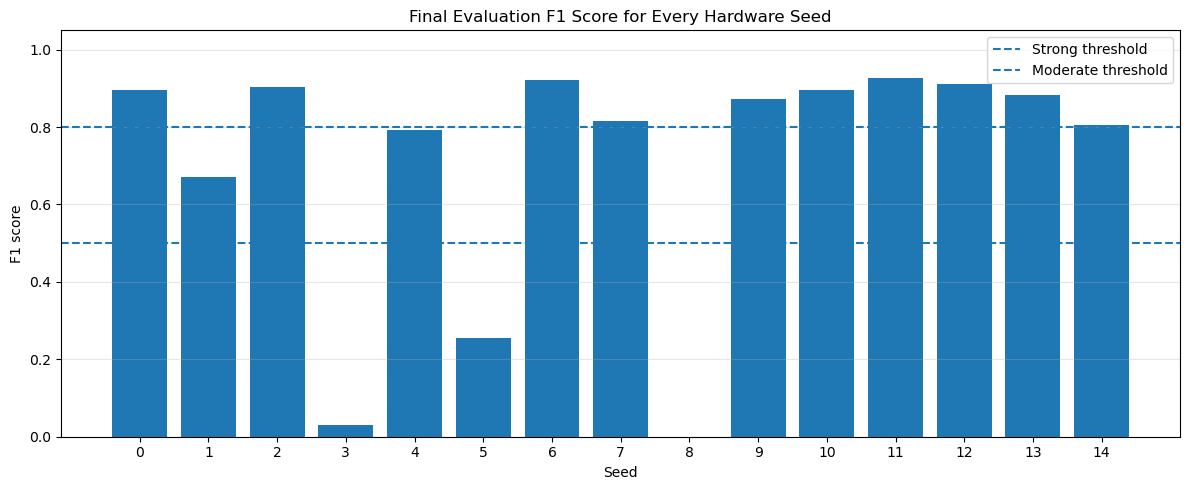

In [31]:
plt.figure(figsize=(12, 5))

plt.bar(summary_df["seed"].astype(str), summary_df["f1_score"])

plt.axhline(0.8, linestyle="--", label="Strong threshold")
plt.axhline(0.5, linestyle="--", label="Moderate threshold")

plt.xlabel("Seed")
plt.ylabel("F1 score")
plt.title("Final Evaluation F1 Score for Every Hardware Seed")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()